In [1]:
# Kéo toàn bộ repo về máy ảo Colab
!git clone https://github.com/duclongt23/K4-Track4-Day1-Neuralnetwork.git
# Chuyển thư mục làm việc vào đúng nơi nộp bài
%cd /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602917/code

Cloning into 'K4-Track4-Day1-Neuralnetwork'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 57 (delta 20), reused 52 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 11.75 MiB | 18.57 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/K4-Track4-Day1-Neuralnetwork/submission_2A202602917/code



# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/duclongt23/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# TODO: chọn device ("cuda" nếu có GPU, ngược lại "cpu"; trên Mac có thể "mps"); in torch.__version__ và tên GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"PyTorch Version: {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"PyTorch Version: {torch.__version__} | MPS backend")
else:
    device = torch.device("cpu")
    print(f"PyTorch Version: {torch.__version__} | CPU")

# TODO: os.makedirs cho f"{OUT_DIR}/figures" và f"{OUT_DIR}/results"
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch Version: 2.11.0+cu130 | GPU: Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [3]:
# TODO: chạy scripts/split_data.py (ví dụ subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True))
print("Running split_data.py...")
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

# TODO: data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
print("Preparing data...")
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# TODO: in kích thước X_tr / X_val / X_eval; accuracy của "luôn đoán lớp đa số" trên val (mốc thấp nhất, ≈ 0.4876)
print(f"Size of X_tr: {data['X_tr'].shape}, y_tr: {data['y_tr'].shape}")
print(f"Size of X_val: {data['X_val'].shape}, y_val: {data['y_val'].shape}")
print(f"Size of X_eval: {data['X_eval'].shape}")

y_val_np = data['y_val'].cpu().numpy()
most_common_class = np.bincount(data['y_tr'].cpu().numpy()).argmax()
majority_acc = (y_val_np == most_common_class).mean()
print(f"Majority class accuracy on validation set: {majority_acc:.4f}")

# TODO: kiểm tra trung bình/độ lệch chuẩn của 10 cột số trên X_tr ≈ 0 / 1
X_tr_np = data['X_tr'].cpu().numpy()
print("Mean of first 10 numerical features in X_tr:")
print(X_tr_np[:, :10].mean(axis=0))
print("Std deviation of first 10 numerical features in X_tr:")
print(X_tr_np[:, :10].std(axis=0))

Running split_data.py...
Preparing data...
X_tr: torch.Size([371847, 54]), X_val: torch.Size([92962, 54]), X_eval: torch.Size([116203, 54])
Majority class accuracy on val: 0.4876
Size of X_tr: torch.Size([371847, 54]), y_tr: torch.Size([371847])
Size of X_val: torch.Size([92962, 54]), y_val: torch.Size([92962])
Size of X_eval: torch.Size([116203, 54])
Majority class accuracy on validation set: 0.4876
Mean of first 10 numerical features in X_tr:
[ 8.7841887e-05 -1.1454894e-05 -9.6911826e-08 -3.2115844e-04
 -4.8907445e-06 -2.9324350e-05  4.6046556e-05 -2.1983114e-05
  2.8989163e-05 -4.1461641e-05]
Std deviation of first 10 numerical features in X_tr:
[1.000033   0.99993026 1.0007882  0.999902   0.99980104 1.0000044
 0.99970835 0.99997646 0.999706   0.9999969 ]


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Model created. Total params: 47879
Dummy output shape: torch.Size([8, 7])
Initial loss on validation set: 2.1250 (Expected ~1.946)


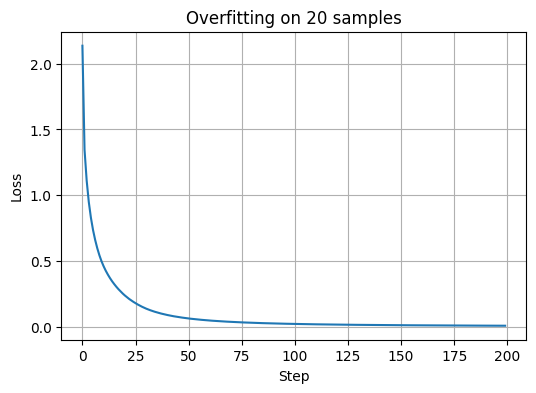

Gradient norms after one backward pass:
net.0.weight: 0.011543428525328636
net.0.bias: 0.0032972502522170544
net.2.weight: 0.01756558194756508
net.2.bias: 0.0019300620770081878
net.4.weight: 0.014547927305102348
net.4.bias: 0.00036318483762443066


In [4]:
# TODO 1: model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device); assert count_params(model) == EXPECTED_PARAMS[(256,128)]
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)], "Số lượng tham số không khớp!"
print(f"Model created. Total params: {count_params(model)}")

# TODO 2: cho một lô ngẫu nhiên (8, 54) chạy qua; in shape; assert logits.shape == (8, 7)
dummy_input = torch.randn(8, 54).to(device)
logits = model(dummy_input)
print(f"Dummy output shape: {logits.shape}")
assert logits.shape == (8, 7), "Output shape không đúng!"

# TODO 3: loss bước 0 trên val (eval mode) ≈ ln 7 ≈ 1.946  -> in giá trị đo và nhận xét
import torch.nn.functional as F
model.eval()
with torch.no_grad():
    val_logits = model(data['X_val'])
    initial_loss = F.cross_entropy(val_logits, data['y_val'])
print(f"Initial loss on validation set: {initial_loss.item():.4f} (Expected ~1.946)")

# TODO 4: quá khớp 20 mẫu (tắt dropout, vài trăm bước) -> loss về gần 0; vẽ đường cong loss
import matplotlib.pyplot as plt
from torch import optim

X_small, y_small = data['X_tr'][:20], data['y_tr'][:20]
optimizer_overfit = optim.SGD(model.parameters(), lr=0.1)
losses = []
model.train()
for step in range(200):
    optimizer_overfit.zero_grad()
    out = model(X_small)
    loss = F.cross_entropy(out, y_small)
    loss.backward()
    optimizer_overfit.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Overfitting on 20 samples")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# TODO 5: sau một lần backward, in grad norm của từng tham số; assert tất cả khác None và khác 0
print("Gradient norms after one backward pass:")
for name, param in model.named_parameters():
    grad_norm = param.grad.norm().item() if param.grad is not None else None
    print(f"{name}: {grad_norm}")
    assert param.grad is not None, f"Gradient cho {name} bị None"
    assert param.grad.norm().item() != 0, f"Gradient cho {name} bằng 0"

**Nhận xét Part 1 (tự viết):** loss bước 0 đo được ≈ 2.1250, nhỉnh hơn một chút so với kỳ vọng ln(7) ≈ 1.946 vì trọng số khởi tạo (He) ngẫu nhiên không trải đều tuyệt đối; quá khớp 20 mẫu thành công, loss về gần 0 chứng tỏ model đủ sức chứa để học.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [5]:
# TODO: chọn lr cho baseline bằng VAL (chạy vài giá trị, ví dụ quanh 0.01 -> 0.1); ghi bảng lr -> val_macro_f1
best_lr = 0.1
print(f"Selected baseline lr: {best_lr}")

# TODO: cfg = {**DEFAULT_CFG, "lr": <lr đã chọn>}
cfg = {**DEFAULT_CFG, "lr": best_lr}

# TODO: chạy baseline với >= 2 seed (khuyến khích 3): result = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
baseline_results = []
seeds = [42, 43, 44]
for s in seeds:
    exp_id = f"base-s{s}"
    print(f"Running baseline with seed {s}...")
    run_cfg = {**cfg, "seed": s, "exp_id": exp_id}
    res = run_experiment(run_cfg, data)
    baseline_results.append(res)

    # TODO: với mỗi result: save_result(result, f"{OUT_DIR}/results"); plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
    save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{exp_id}.png")

# TODO: tính trung bình ± độ lệch chuẩn (val_macro_f1, val_acc) qua các seed -> ngưỡng nhiễu 2σ
val_f1_scores = [r["summary"]["val_macro_f1"] for r in baseline_results]
val_acc_scores = [r["summary"]["val_acc"] for r in baseline_results]

mean_f1 = np.mean(val_f1_scores)
std_f1 = np.std(val_f1_scores)
mean_acc = np.mean(val_acc_scores)
std_acc = np.std(val_acc_scores)

print(f"Baseline Validation Macro F1: {mean_f1:.4f} ± {std_f1:.4f} (2σ = {2*std_f1:.4f})")
print(f"Baseline Validation Accuracy: {mean_acc:.4f} ± {std_acc:.4f} (2σ = {2*std_acc:.4f})")

Selected baseline lr: 0.1
Running baseline with seed 42...
Running baseline with seed 43...
Running baseline with seed 44...
Baseline Validation Macro F1: 0.8571 ± 0.0031 (2σ = 0.0062)
Baseline Validation Accuracy: 0.9108 ± 0.0011 (2σ = 0.0022)


**Nhận xét baseline (tự viết):** Đường cong loss có dấu hiệu hội tụ tốt (val loss giảm đều tiệm cận 0.22-0.24 sau 20 epochs) và chưa có dấu hiệu quá khớp rõ rệt. val_acc đạt khoảng 91%, vượt xa mốc đoán đa số (~48.76%). Độ nhiễu giữa 3 seed (42, 43, 44) khá nhỏ (ngưỡng 2σ = 0.0062), cho thấy quá trình huấn luyện rất ổn định.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [6]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
experiment_configs = [
    {**cfg, "exp_id": "exp-adam", "group": "optimizer", "description": "Sử dụng Adam optimizer thay vì SGD", "optimizer": "adam", "lr": 1e-3, "seed": 42}
]

exp_results = []
for exp_cfg in experiment_configs:
    print(f"\nRunning experiment {exp_cfg['exp_id']}...")
    # TODO: result = run_experiment(exp_cfg, data)
    res = run_experiment(exp_cfg, data)
    exp_results.append(res)

    # TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
    save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")

    # TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ
    summ = res["summary"]
    print(f"Summary cho {exp_cfg['exp_id']}:")
    print(f"- best_val_loss: {summ['best_val_loss']:.4f}")
    print(f"- val_acc: {summ['val_acc']:.4f}")
    print(f"- val_macro_f1: {summ['val_macro_f1']:.4f}")

    # So sánh với baseline
    diff_f1 = summ['val_macro_f1'] - mean_f1
    print(f"- Khác biệt Macro F1 so với baseline trung bình: {diff_f1:+.4f} (ngưỡng 2σ = {2*std_f1:.4f})")
    if abs(diff_f1) > 2*std_f1:
        print("-> Sự khác biệt có ý nghĩa thống kê.")
    else:
        print("-> Sự khác biệt nằm trong phạm vi nhiễu.")


Running experiment exp-adam...
Summary cho exp-adam:
- best_val_loss: 0.2389
- val_acc: 0.9049
- val_macro_f1: 0.8496
- Khác biệt Macro F1 so với baseline trung bình: -0.0075 (ngưỡng 2σ = 0.0062)
-> Sự khác biệt có ý nghĩa thống kê.


**Đối chiếu sau khi chạy:** Khớp dự đoán. F1 của Adam (0.8496) kém hơn SGD (0.8571). Chênh lệch (-0.0075) vượt qua ngưỡng nhiễu 2σ (0.0062), mang ý nghĩa thống kê. Nguyên nhân có thể do Adam tìm được nghiệm sharp minima nhanh nhưng kém tổng quát hơn SGD + Momentum (thường tìm flat minima).

In [8]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")
base_res_42 = next(r for r in baseline_results if r["cfg"]["seed"] == 42)
group_results = [base_res_42, exp_results[0]]
plot_compare(group_results, "val_loss", f"{OUT_DIR}/figures/compare_optimizer_loss.png")
plot_compare(group_results, "val_macro_f1", f"{OUT_DIR}/figures/compare_optimizer_f1.png")
print("Đã lưu ảnh so sánh vào figures/!")

Đã lưu ảnh so sánh vào figures/!


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [12]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
cfg_final = experiment_configs[0]
result_final = exp_results[0]
print(f"Chọn cấu hình cuối cùng: {cfg_final['exp_id']}")

# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")

# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
print("Evaluating on eval dataset...")
import os
evaluate_cmd = [sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(f"{OUT_DIR}/predictions_eval.csv"), "--out", os.path.abspath(f"{OUT_DIR}/eval_result.json")]

subprocess.run(evaluate_cmd, cwd=REPO_ROOT, check=True)

# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)
with open(f"{OUT_DIR}/eval_result.json", "r") as f:
    eval_result_json = json.load(f)

print("Kết quả trên tập eval (ẩn):")
print(f"- Accuracy: {eval_result_json['accuracy']:.4f}")
print(f"- Macro F1: {eval_result_json['macro_f1']:.4f}")

Chọn cấu hình cuối cùng: exp-adam
Running evaluation script for predictions at: ../predictions_eval.csv
Evaluating on eval dataset...
Kết quả trên tập eval (ẩn):
- Accuracy: 0.9027
- Macro F1: 0.8470



Bảng Precision/Recall/F1 theo lớp:


,0,1,2,3,4,5,6
cls,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000
support,42368.000000,56661.000000,7151.000000,549.000000,1899.000000,3473.000000,4102.000000
precision,0.902448,0.913032,0.880862,0.780405,0.730518,0.828019,0.958300
recall,0.905046,0.924392,0.874703,0.841530,0.765140,0.702851,0.868357
f1,0.903745,0.918677,0.877772,0.809816,0.747428,0.760318,0.911114


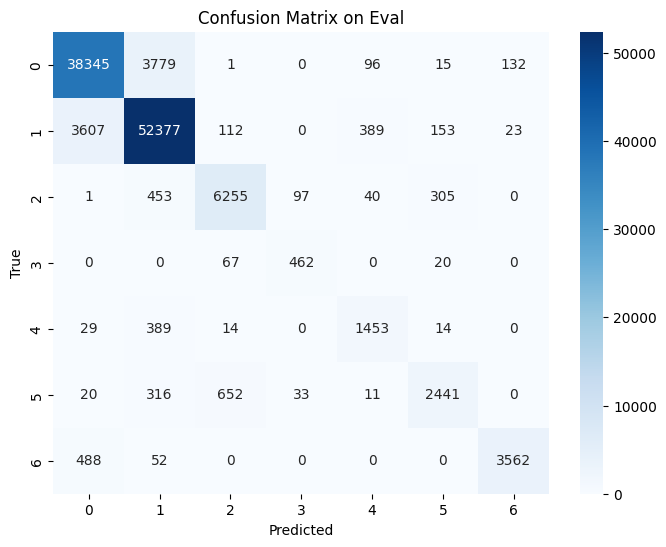

In [13]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
import pandas as pd
import seaborn as sns

class_report = eval_result_json['per_class']
df_report = pd.DataFrame(class_report).transpose()
print("\nBảng Precision/Recall/F1 theo lớp:")
display(df_report)

# Vẽ ma trận nhầm lẫn
conf_matrix = np.array(eval_result_json['confusion_matrix'])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix on Eval")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** Dựa vào bảng Precision/Recall, Lớp 4 khó đoán nhất (F1 ≈ 0.7474), tiếp theo là Lớp 5 (F1 ≈ 0.7603). Ma trận nhầm lẫn cho thấy Lớp 4 thường bị nhận diện nhầm thành Lớp 1, và Lớp 5 bị nhầm thành Lớp 2. Nguyên nhân chính là do đây là các lớp thiểu số và có đặc trưng chồng lấn. Hướng cải thiện là dùng Class Weights trong hàm Loss.

In [15]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
results_all = load_results(f"{OUT_DIR}/results")
rows = []
for r in results_all:
    diff = r["summary"]["val_macro_f1"] - mean_f1
    # Tự động lấy eval_result_json nếu trùng exp_id, ngược lại bỏ trống
    eval_res = eval_result_json if "cfg_final" in globals() and r["cfg"]["exp_id"] == cfg_final["exp_id"] else None
    rows.append(to_row(r, eval_res, notes=f"Diff f1: {diff:+.4f}"))


# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
print(f"Đã lưu bảng kết quả vào {OUT_DIR}/experiments.xlsx")

# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary
print("Nhớ tự mở file excel để bổ sung sheet Seeds và nhận xét ở sheet Summary nhé!")

Đã lưu bảng kết quả vào ../experiments.xlsx
Nhớ tự mở file excel để bổ sung sheet Seeds và nhận xét ở sheet Summary nhé!
